In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df['datetime'] = pd.to_datetime(df['dteday']) + pd.to_timedelta(df['hr'], unit='h')

In [4]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,datetime
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,2011-01-01 00:00:00
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,2011-01-01 01:00:00
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,2011-01-01 02:00:00
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,2011-01-01 03:00:00
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,2011-01-01 04:00:00


In [5]:
df = df.sort_values('datetime').reset_index(drop=True)


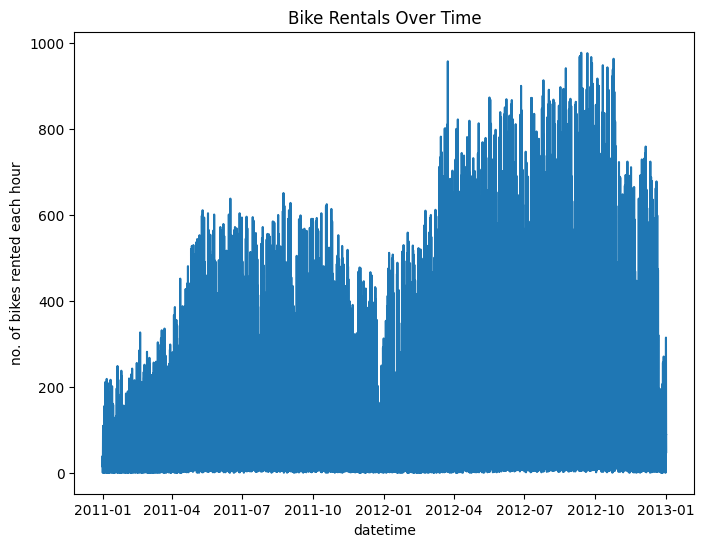

In [6]:
plt.figure(figsize=(8,6))
plt.xlabel("datetime")
plt.ylabel("no. of bikes rented each hour")
plt.title("Bike Rentals Over Time")
plt.plot(df['datetime'], df['cnt'])
plt.show()

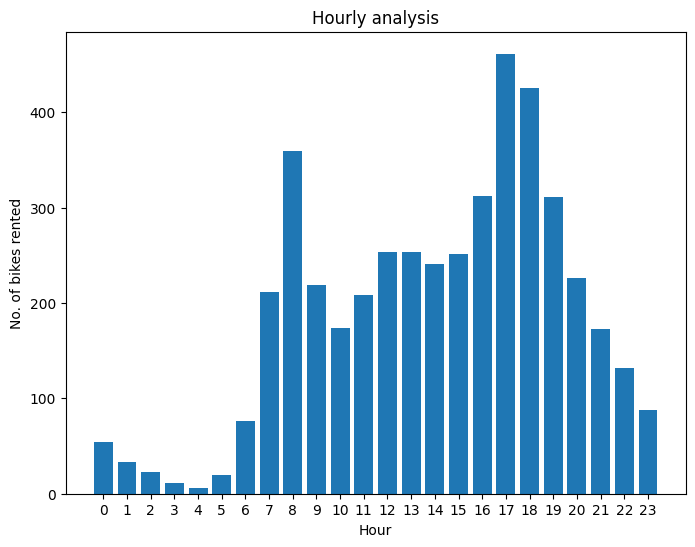

In [7]:
plt.figure(figsize=(8,6))
hourly= df.groupby('hr')['cnt'].mean()
plt.xlabel("Hour")
plt.ylabel("No. of bikes rented")
plt.title("Hourly analysis")
plt.bar(hourly.index, hourly.values)
plt.xticks(range(24))
plt.show()

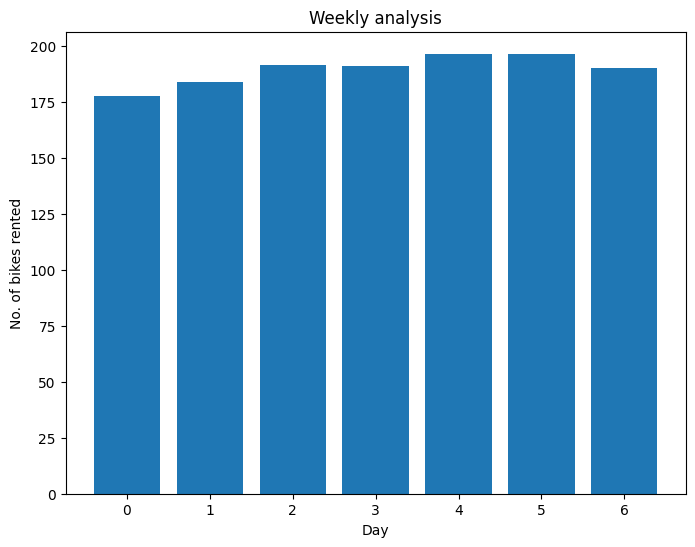

In [8]:
plt.figure(figsize=(8,6))
weekday = df.groupby('weekday')['cnt'].mean()
plt.xlabel("Day")
plt.ylabel("No. of bikes rented")
plt.title("Weekly analysis")
plt.bar(weekday.index , weekday.values)
plt.xticks(range(7))
plt.show()

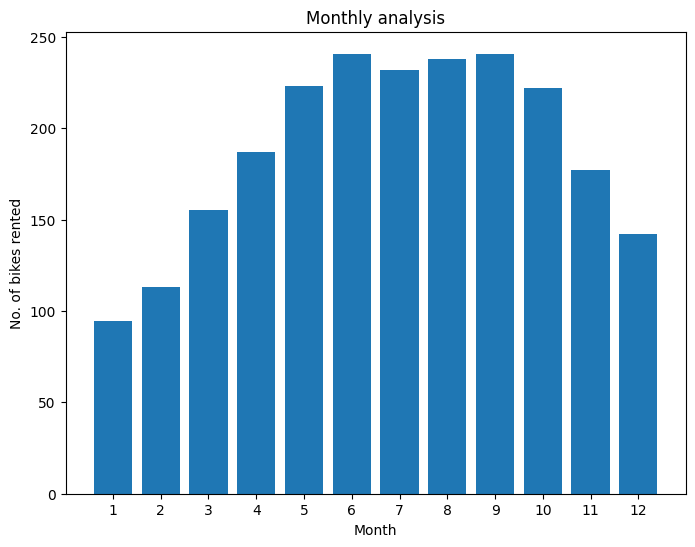

In [9]:
plt.figure(figsize=(8,6))
month=df.groupby('mnth')['cnt'].mean()
plt.bar(month.index , month.values)
plt.xlabel("Month")
plt.ylabel("No. of bikes rented")
plt.title("Monthly analysis")
plt.xticks(range(1,13))
plt.show()


<Figure size 800x600 with 0 Axes>

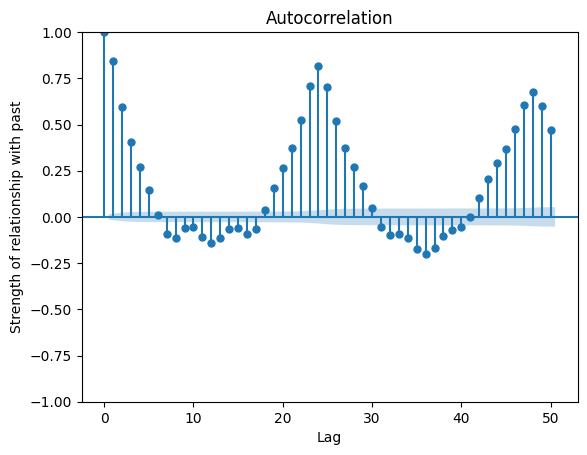

In [10]:
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(8,6))
plot_acf(df['cnt'], lags=50)
plt.xlabel("Lag")
plt.ylabel("Strength of relationship with past")
plt.show()

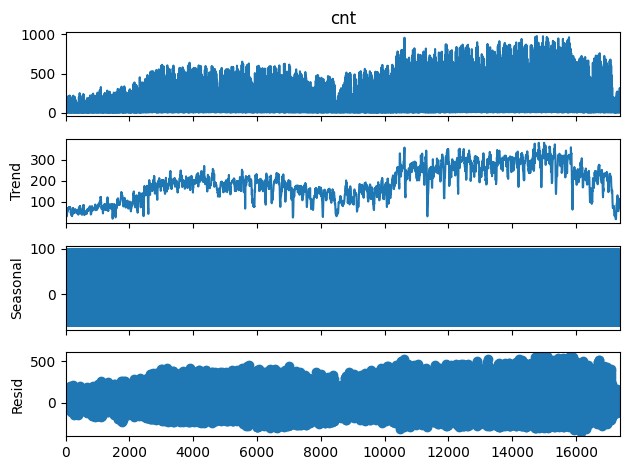

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['cnt'], period =24)
result.plot()
plt.show()

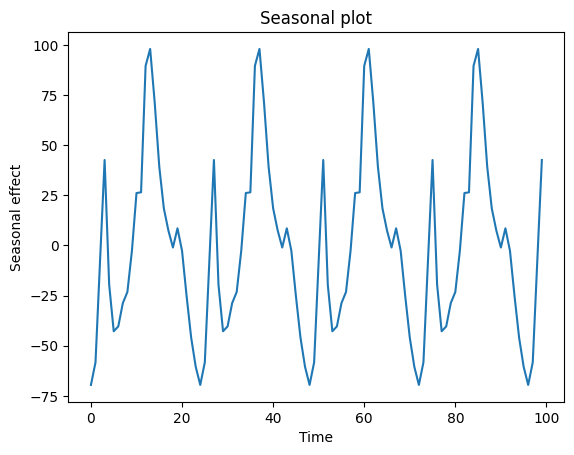

In [12]:
result.seasonal[:100].plot()
plt.xlabel("Time")
plt.ylabel("Seasonal effect")
plt.title("Seasonal plot")
plt.show()

In [13]:
df['hour']=df['hr']
df['day']=df['weekday']
df['month']=df['mnth']
df['lag1']=df['cnt'].shift(1)
df['lag24']=df['cnt'].shift(24)
df['rolling']=df['cnt'].rolling(24).mean()
df=df.dropna()
df.head()



,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,casual,registered,cnt,datetime,hour,day,month,lag1,lag24,rolling
24,25,2011-01-02,1,0,1,0,0,0,0,2,...,4,13,17,2011-01-02 00:00:00,0,0,1,39.0,16.0,41.083333
25,26,2011-01-02,1,0,1,1,0,0,0,2,...,1,16,17,2011-01-02 01:00:00,1,0,1,17.0,40.0,40.125000
26,27,2011-01-02,1,0,1,2,0,0,0,2,...,1,8,9,2011-01-02 02:00:00,2,0,1,17.0,32.0,39.166667
27,28,2011-01-02,1,0,1,3,0,0,0,2,...,2,4,6,2011-01-02 03:00:00,3,0,1,9.0,13.0,38.875000
28,29,2011-01-02,1,0,1,4,0,0,0,2,...,2,1,3,2011-01-02 04:00:00,4,0,1,6.0,1.0,38.958333


In [14]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'datetime', 'hour', 'day', 'month',
       'lag1', 'lag24', 'rolling'],
      dtype='object')

In [15]:
train=df.iloc[:int(0.6*len(df))]
valid=df.iloc[int(0.6*len(df)): int(0.8*len(df))]
test = df.iloc[int(0.8*len(df)):]


In [16]:
df = df.drop(columns=['casual', 'registered', 'instant', 'dteday', 'datetime'])

In [17]:
features = df.columns.drop('cnt')

x_train = train[features]
y_train = train['cnt']

x_valid = valid[features]
y_valid = valid['cnt']

x_test = test[features]
y_test=test['cnt']


In [18]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_valid=scaler.transform(x_valid)
x_test=scaler.transform(x_test)



In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(x_train,y_train)

print(model)

RandomForestRegressor()


In [20]:
from sklearn.metrics import mean_absolute_error , mean_squared_error

y_pred_valid=model.predict(x_valid)

print("MAE: ", mean_absolute_error(y_valid, y_pred_valid))
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, y_pred_valid)))

MAE:  50.365652549697494
RMSE:  81.3035173947988


In [21]:
y_pred_test = model.predict(x_test)

print("test MAE:", mean_absolute_error(y_test, y_pred_test))
print("test RMSE: ", np.sqrt(mean_squared_error(y_test,y_pred_test)))

test MAE: 49.33515989628349
test RMSE:  84.37800954164042


In [22]:
baseline = test['lag1']

print("baseline MAE:", mean_absolute_error(y_test, baseline))
print("baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline)))

baseline MAE: 85.22097378277154
baseline RMSE: 129.71585639233416


In [23]:
baseline = test['lag24']

print("baseline MAE:", mean_absolute_error(y_test, baseline))
print("baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline)))

baseline MAE: 80.54681647940075
baseline RMSE: 134.85284829889358
